<a href="https://colab.research.google.com/github/biswas-bit/Deep-learning/blob/main/cat_vs_dog_bbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [130]:
import tensorflow as tf
import numpy as np
import os, glob
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [131]:
print(tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [132]:
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
!wget https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
!tar -xzf images.tar.gz
!tar -xzf annotations.tar.gz

--2026-07-16 15:56:26--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/images.tar.gz
Resolving www.robots.ox.ac.uk (www.robots.ox.ac.uk)... 129.67.94.2
Connecting to www.robots.ox.ac.uk (www.robots.ox.ac.uk)|129.67.94.2|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://thor.robots.ox.ac.uk/pets/images.tar.gz [following]
--2026-07-16 15:56:26--  https://thor.robots.ox.ac.uk/pets/images.tar.gz
Resolving thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)... 129.67.95.98
Connecting to thor.robots.ox.ac.uk (thor.robots.ox.ac.uk)|129.67.95.98|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 791918971 (755M) [application/octet-stream]
Saving to: ‘images.tar.gz.1’

images.tar.gz.1     100%[===================>] 755.23M  54.4MB/s    in 11s     

2026-07-16 15:56:38 (66.9 MB/s) - ‘images.tar.gz.1’ saved [791918971/791918971]

--2026-07-16 15:56:38--  https://www.robots.ox.ac.uk/~vgg/data/pets/data/annotations.tar.gz
Resolving w

In [133]:
IMG_DIR = "images"
XML_DIR = "annotations/xmls"

print("Total images", len(os.listdir(IMG_DIR)))
print("Total with bbox annotations", len(os.listdir(XML_DIR)))

Total images 7393
Total with bbox annotations 3686


In [134]:
sample_xml = glob.glob(os.path.join(XML_DIR, "*.xml"))[0]
with open(sample_xml, "r") as f:
  print(f.read())

<annotation><folder>OXIIIT</folder><filename>Ragdoll_146.jpg</filename><source><database>OXFORD-IIIT Pet Dataset</database><annotation>OXIIIT</annotation><image>flickr</image></source><size><width>500</width><height>375</height><depth>3</depth></size><segmented>0</segmented><object><name>cat</name><pose>Frontal</pose><truncated>0</truncated><occluded>0</occluded><bndbox><xmin>206</xmin><ymin>79</ymin><xmax>279</xmax><ymax>146</ymax></bndbox><difficult>0</difficult></object></annotation>



In [135]:
# parsing turn xml into (path, label, box) tuples
def parse_annotation(xml_path):
  tree = ET.parse(xml_path)
  root = tree.getroot()
  filename = root.find("filename").text
  img_path = os.path.join(IMG_DIR, filename)
  if not img_path.lower().endswith((".jpg", ".jpeg", ".png")):
    img_path += ".jpg"

  size = root.find("size")
  w, h = int(size.find("width").text), int(size.find("height").text)
  obj = root.find("object")
  name = obj.find("name").text.lower()
  label = 0 if name == "cat" else 1

  bbox = obj.find("bndbox")
  xmin = int(bbox.find("xmin").text)/ w
  ymin = int(bbox.find("ymin").text)/ h
  xmax = int(bbox.find("xmax").text)/ w
  ymax = int(bbox.find("ymax").text)/ h

  return img_path, label, [xmin, ymin, xmax, ymax]

In [136]:
xml_files = glob.glob(os.path.join(XML_DIR, "*.xml"))
records = [parse_annotation(f) for f in xml_files]
records = [r for r in records if os.path.exists(r[0])]
print("Usable samples:", len(records))

Usable samples: 3686


In [137]:
def show_sample(path, label, box):
    img = plt.imread(path)
    h, w = img.shape[0], img.shape[1]
    fig, ax = plt.subplots(1)
    ax.imshow(img)
    xmin, ymin, xmax, ymax = box
    rect = patches.Rectangle((xmin*w, ymin*h), (xmax-xmin)*w, (ymax-ymin)*h, linewidth=2, edgecolor='g', facecolor='none')
    ax.add_patch(rect)

    # Determine the label text
    label_text = "Cat" if label == 0 else "Dog"

    # Add the label text to the plot
    ax.text(xmin*w, ymin*h - 10, label_text, color='red', fontsize=12, fontweight='bold')
    plt.show()

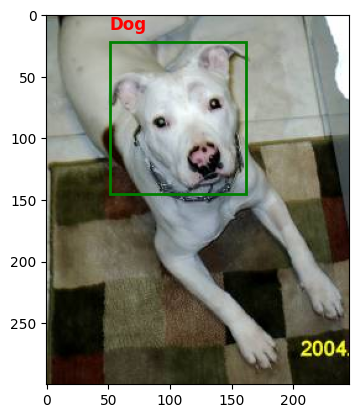

In [138]:
path, label, box = records[40]
show_sample(path, label, box)

In [139]:
img_paths = [r[0] for r in records]
labels = np.array([r[1] for r in records], dtype = np.float32)
bboxes = np.array([r[2] for r in records], dtype = np.float32)

n = len(img_paths)
idx = np.random.permutation(n)
split = int(0.85*n)
train_idx , val_idx = idx[:split], idx[split:]
print("Train Samples", len(train_idx))
print("Val Samples", len(val_idx))

Train Samples 3133
Val Samples 553


In [140]:
# building the pipeline
def load_and_preprocess(path, label, bbox):
  img = tf.io.read_file(path)
  img = tf.image.decode_jpeg(img, channels=3)
  img = tf.image.resize(img, (224, 224))
  img = img/255.0
  return img , {"class_output":label, "bbox_output":bbox}

def make_ds(indices, shuffle = False):
  ds = tf.data.Dataset.from_tensor_slices((np.array(img_paths)[indices], labels[indices], bboxes[indices]))
  if shuffle:
    ds = ds.shuffle(1000)
  ds = ds.map(load_and_preprocess, num_parallel_calls =  tf.data.AUTOTUNE)
  ds = ds.batch(32).prefetch(tf.data.AUTOTUNE)
  return ds


In [141]:
train_ds = make_ds(train_idx, shuffle = True)
val_ds = make_ds(val_idx, shuffle=True)

In [142]:
for imgs, targets in train_ds.take(1):
    print("Image batch shape:", imgs.shape)
    print("Class batch shape:", targets["class_output"].shape)
    print("Bbox batch shape:", targets["bbox_output"].shape)

Image batch shape: (32, 224, 224, 3)
Class batch shape: (32,)
Bbox batch shape: (32, 4)


In [143]:
from tensorflow.keras import layers, models, applications
base_model = applications.MobileNetV2(
    input_shape = (224, 224,3),
    include_top = False,
    weights = "imagenet"
)

base_model.trainable = False

In [144]:
inputs = layers.Input(shape=(224, 224,3))
# Get the output tensor from the base_model
base_features = base_model(inputs, training=False)
pooled_features = layers.GlobalAveragePooling2D()(base_features)
dense_output = layers.Dense(256, activation="relu")(pooled_features)
x = layers.Dropout(0.3)(dense_output)

In [145]:
#classification head
class_branch = layers.Dense(64, activation="relu")(x)
class_output = layers.Dense(1, activation="sigmoid", name="class_output")(class_branch)

# bounding box regression head
bbox_branch = layers.Dense(64, activation='relu')(x)
bbox_branch = layers.Dropout(0.3)(bbox_branch)
bbox_output = layers.Dense(4, activation="sigmoid", name="bbox_output")(bbox_branch)

model = models.Model(inputs=inputs, outputs = [class_output, bbox_output])
model.summary()

Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_1.00_2… │ (None, 7, 7,      │  2,257,984 │ input_layer_7[0]… │
│ (Functional)        │ 1280)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 1280)      │          0 │ mobilenetv2_1.00… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 256)       │    327,936 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 256)       │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_14 (Dense)    │ (None, 64)        │     16,448 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 64)        │     16,448 │ dropout_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_6 (Dropout) │ (None, 64)        │          0 │ dense_14[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 1)         │         65 │ dense_13[0][0]    │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bbox_output (Dense) │ (None, 4)         │        260 │ dropout_6[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,619,141 (9.99 MB)

 Trainable params: 361,157 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

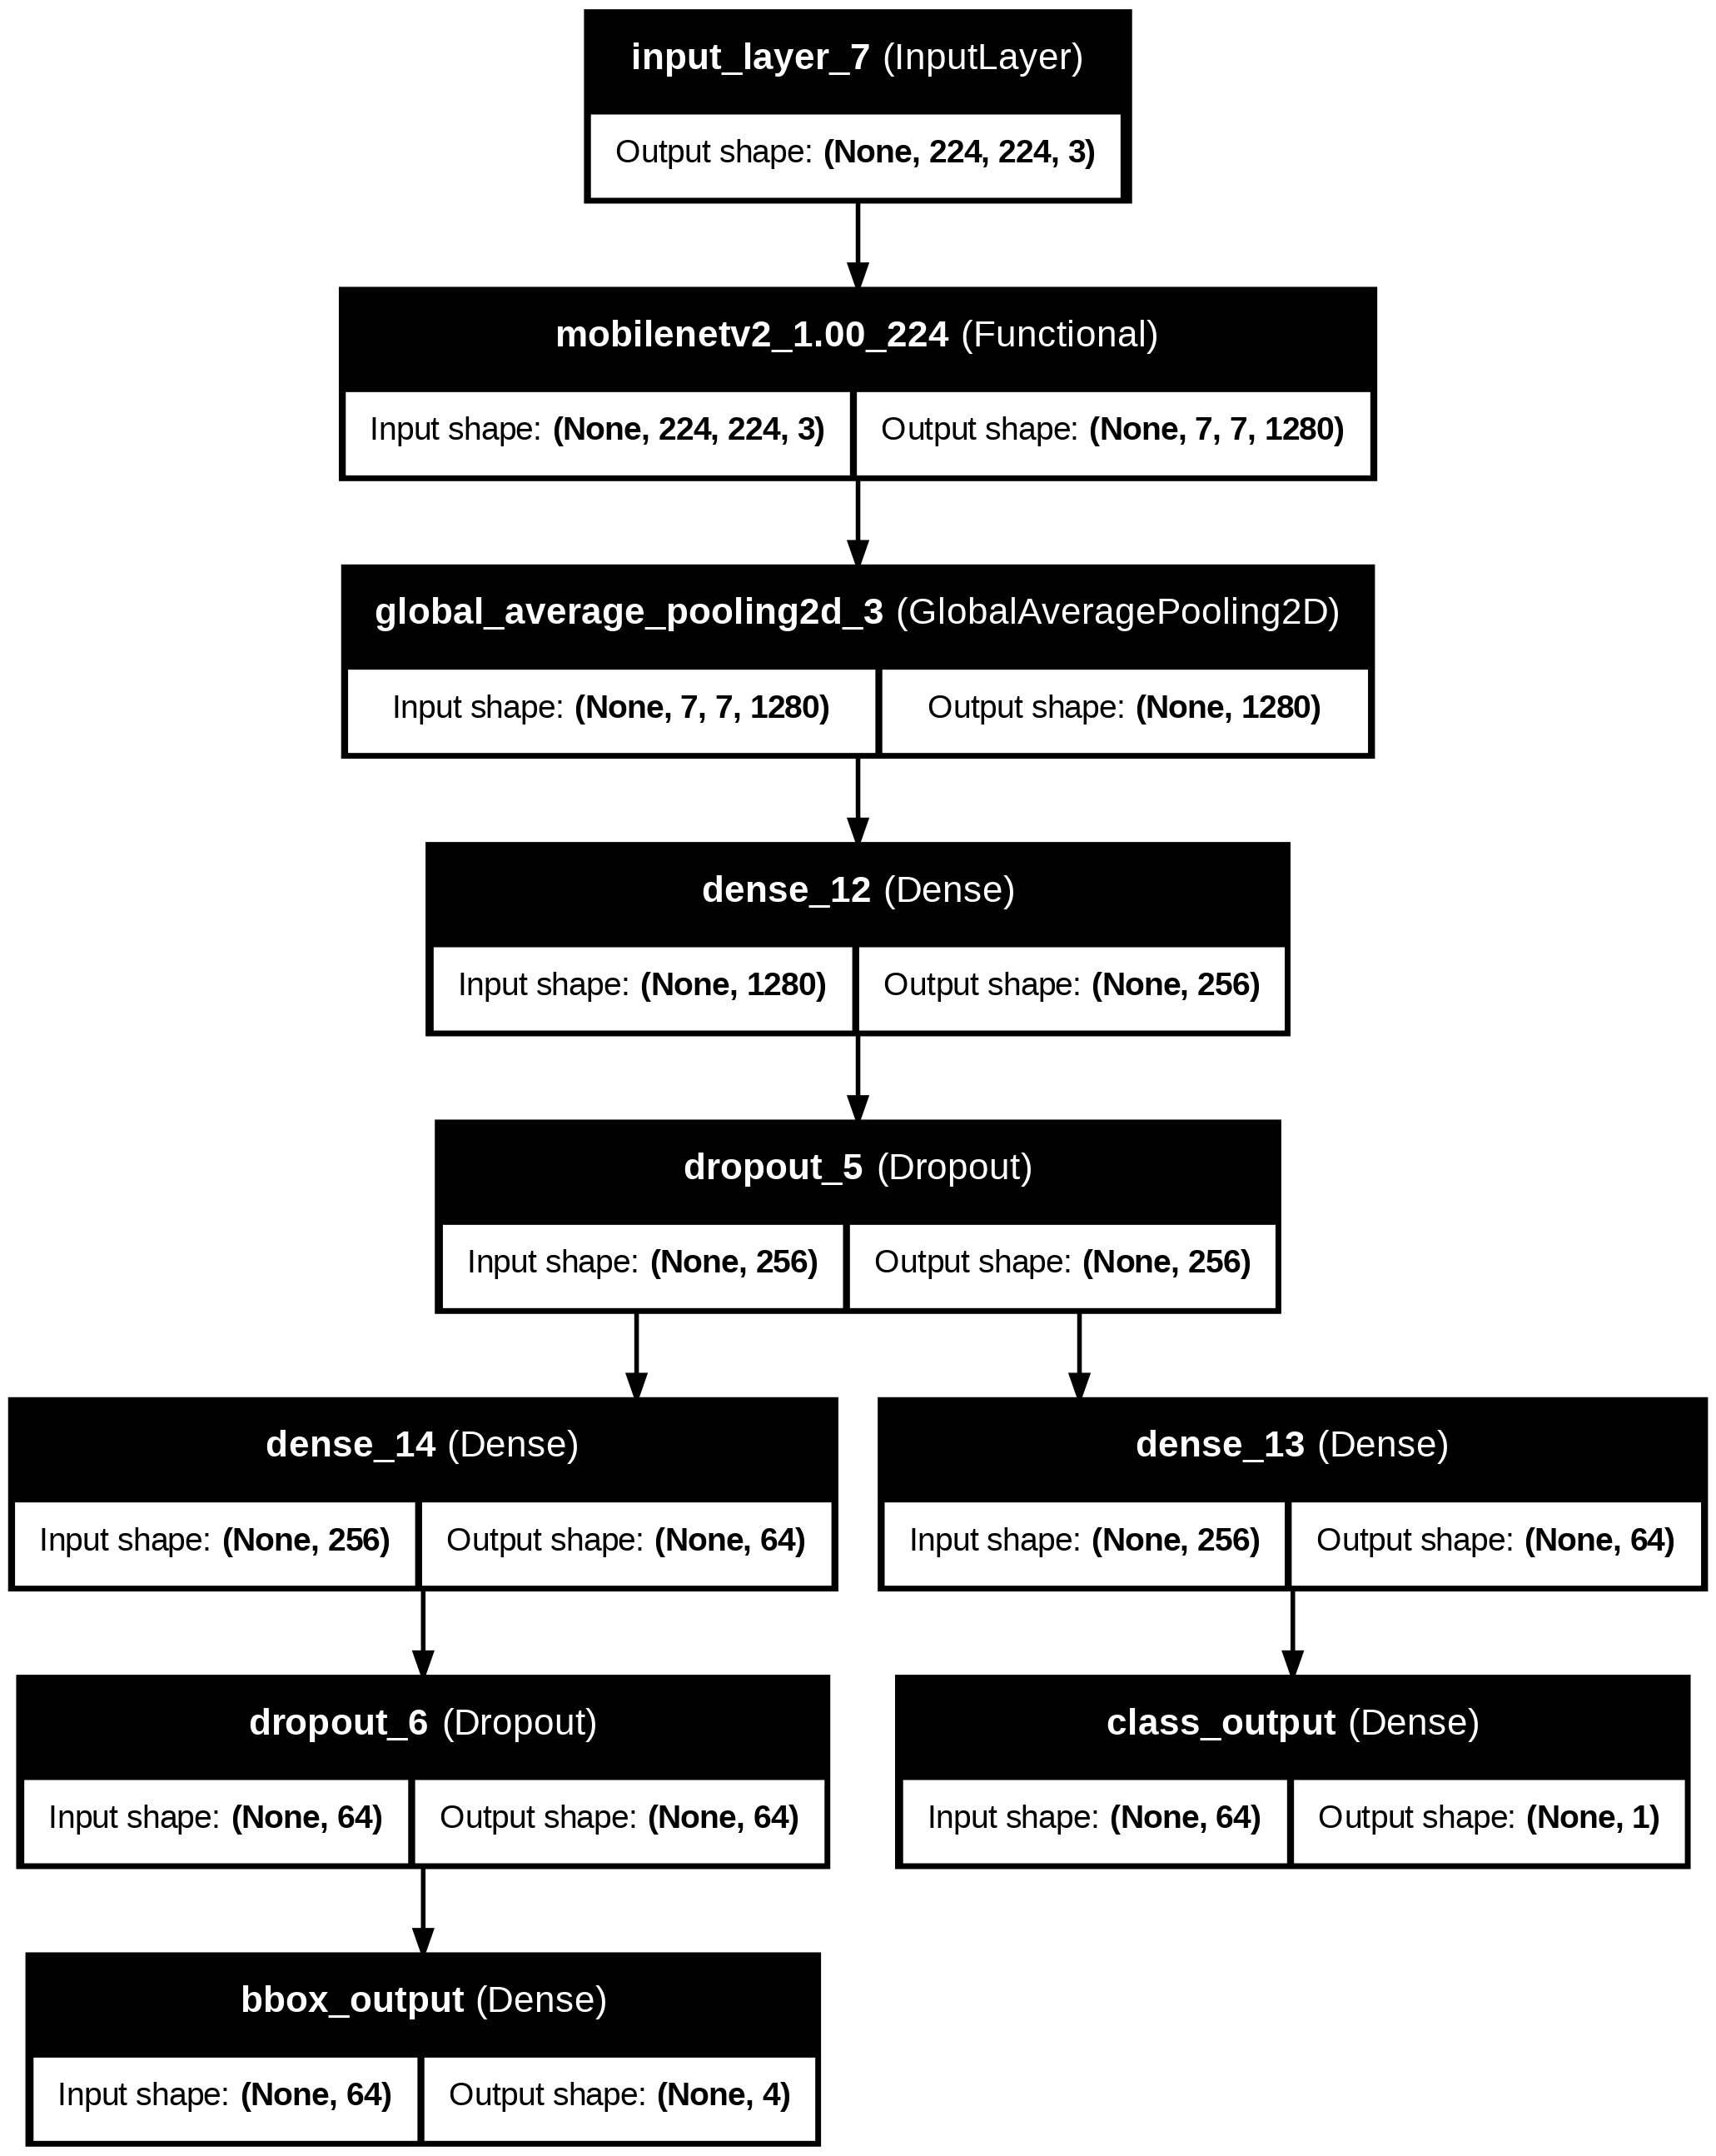

In [146]:
from tensorflow.keras.utils import plot_model
plot_model(model, show_layer_names=True, show_shapes=True, to_file='model.png')

In [147]:
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 1e-3),
    loss = {
        "class_output": "binary_crossentropy",
        "bbox_output": "mse"
    },
    loss_weights = {
        "class_output":1.0,
        "bbox_output":5.0
    },

    metrics = {
        "class_output":"accuracy",
        "bbox_output":"mae"
    }
)

In [148]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor = "val_bbox_output_mae",
    save_best_only = True,
    mode = "min"
)

early_stop = EarlyStopping(
    monitor = "val_bbox_output_mae",
    patience = 4,
    restore_best_weights = True,
    mode = "min"
)

In [149]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks = [checkpoint, early_stop]
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 35s 235ms/step - bbox_output_loss: 0.0325 - bbox_output_mae: 0.1406 - class_output_accuracy: 0.9726 - class_output_loss: 0.0725 - loss: 0.2352 - val_bbox_output_loss: 0.0179 - val_bbox_output_mae: 0.1068 - val_class_output_accuracy: 0.9910 - val_class_output_loss: 0.0222 - val_loss: 0.1103
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 101ms/step - bbox_output_loss: 0.0218 - bbox_output_mae: 0.1165 - class_output_accuracy: 0.9907 - class_output_loss: 0.0225 - loss: 0.1317 - val_bbox_output_loss: 0.0170 - val_bbox_output_mae: 0.1033 - val_class_output_accuracy: 0.9928 - val_class_output_loss: 0.0158 - val_loss: 0.1011
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 100ms/step - bbox_output_loss: 0.0199 - bbox_output_mae: 0.1112 - class_output_accuracy: 0.9923 - class_output_loss: 0.0183 - loss: 0.1178 - val_bbox_output_loss: 0.0163 - val_bbox_output_mae: 0.1005 - val_class_output_accuracy: 0.9928 - val_class_output_loss: 0.0161 - val_loss: 0.0979
Epoch 4/10
98

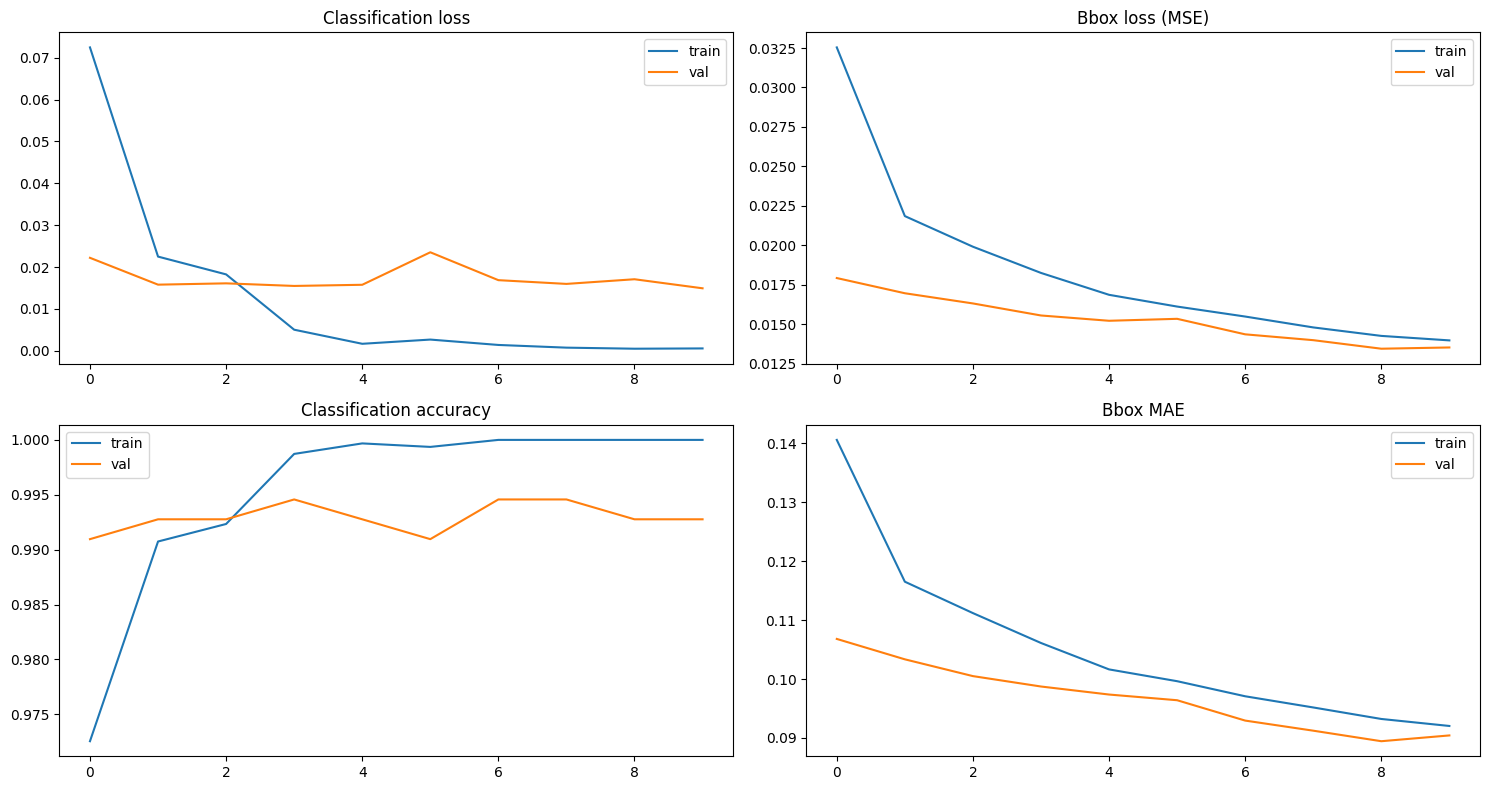

In [150]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 8)) # Changed to 2 rows, 2 columns

# Flatten axes array for easier indexing if needed, or index directly
# Classification Loss
axes[0, 0].plot(history.history['class_output_loss'], label='train')
axes[0, 0].plot(history.history['val_class_output_loss'], label='val')
axes[0, 0].set_title('Classification loss')
axes[0, 0].legend()

# Bbox Loss (MSE)
axes[0, 1].plot(history.history['bbox_output_loss'], label='train')
axes[0, 1].plot(history.history['val_bbox_output_loss'], label='val')
axes[0, 1].set_title('Bbox loss (MSE)')
axes[0, 1].legend()

# Classification Accuracy
axes[1, 0].plot(history.history['class_output_accuracy'], label='train')
axes[1, 0].plot(history.history['val_class_output_accuracy'], label='val')
axes[1, 0].set_title('Classification accuracy')
axes[1, 0].legend()

# Bbox MAE (added)
axes[1, 1].plot(history.history['bbox_output_mae'], label='train')
axes[1, 1].plot(history.history['val_bbox_output_mae'], label='val')
axes[1, 1].set_title('Bbox MAE')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

In [151]:
def predict_single_image(img_path, model):
    # 1. Load and preprocess EXACTLY like training
    img_raw = tf.io.read_file(img_path)
    img_decoded = tf.image.decode_jpeg(img_raw, channels=3)
    img_resized = tf.image.resize(img_decoded, (224, 224))
    img_normalized = img_resized / 255.0

    # 2. Add batch dimension — model expects (batch, H, W, C), not (H, W, C)
    img_batch = tf.expand_dims(img_normalized, axis=0)

    # 3. Predict
    pred_class, pred_bbox = model.predict(img_batch, verbose=0)

    pred_label = "dog" if pred_class[0][0] >= 0.5 else "cat"
    confidence = pred_class[0][0] if pred_label == "dog" else 1 - pred_class[0][0]
    box = pred_bbox[0]  # [xmin, ymin, xmax, ymax], normalized 0-1

    return pred_label, confidence, box, img_decoded.numpy()

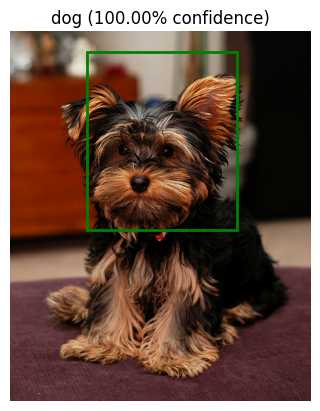

In [152]:
def show_prediction(img_path, model):
    label, conf, box, img = predict_single_image(img_path, model)
    h, w = img.shape[0], img.shape[1]

    xmin, ymin, xmax, ymax = box
    fig, ax = plt.subplots(1)
    ax.imshow(img)
    rect = patches.Rectangle(
        (xmin * w, ymin * h), (xmax - xmin) * w, (ymax - ymin) * h,
        linewidth=2, edgecolor='green', facecolor='none'
    )
    ax.add_patch(rect)
    ax.set_title(f"{label} ({conf:.2%} confidence)")
    ax.axis('off')
    plt.show()

# try it on a validation image you haven't "seen" in your head yet
test_path = img_paths[val_idx[0]]
show_prediction(test_path, model)

In [153]:
model.save("cat_dog_bbox_model.keras")

In [154]:
loaded_model = tf.keras.models.load_model("/content/cat_dog_bbox_model.keras")
label, conf, box, img = predict_single_image(img_paths[val_idx[0]], loaded_model)
print(label, conf, box)

dog 0.9999933 [0.2545831  0.05547175 0.7539479  0.5372821 ]


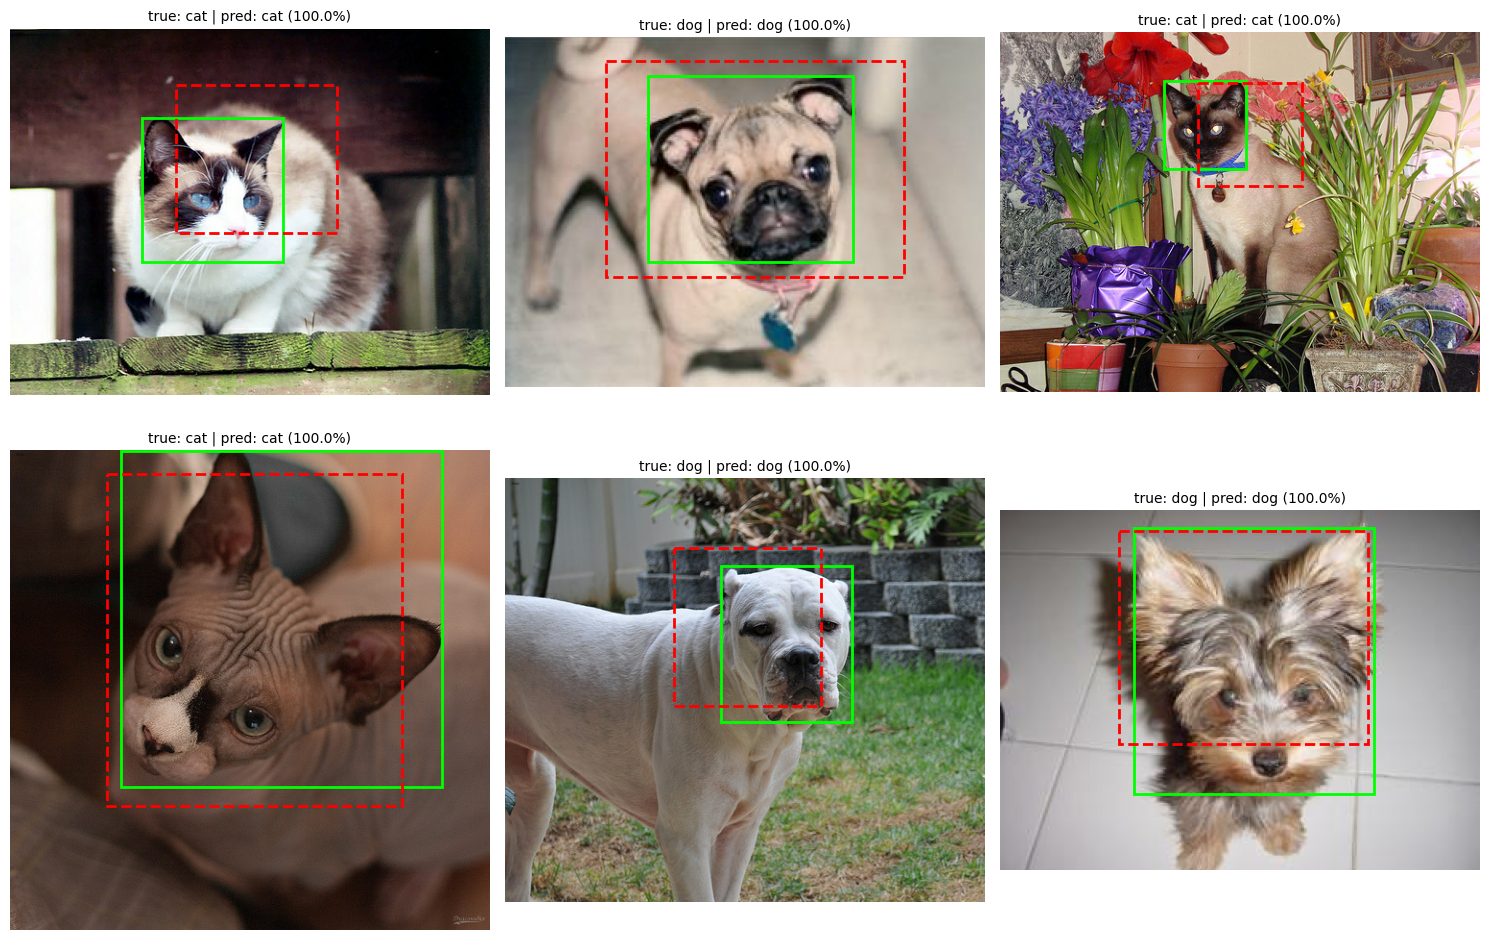

In [155]:
def show_predictions_grid(indices, model, records, n=6):
    n = min(n, len(indices))
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()

    for i in range(n):
        idx = indices[i]
        img_path, true_label_idx, true_box = records[idx]

        pred_label, conf, pred_box, img = predict_single_image(img_path, model)
        h, w = img.shape[0], img.shape[1]

        ax = axes[i]
        ax.imshow(img)

        # Ground truth box in green
        xmin, ymin, xmax, ymax = true_box
        gt_rect = patches.Rectangle(
            (xmin * w, ymin * h), (xmax - xmin) * w, (ymax - ymin) * h,
            linewidth=2, edgecolor='lime', facecolor='none', label='ground truth'
        )
        ax.add_patch(gt_rect)

        # Predicted box in red
        xmin, ymin, xmax, ymax = pred_box
        pred_rect = patches.Rectangle(
            (xmin * w, ymin * h), (xmax - xmin) * w, (ymax - ymin) * h,
            linewidth=2, edgecolor='red', facecolor='none', linestyle='--', label='predicted'
        )
        ax.add_patch(pred_rect)

        true_label = "cat" if true_label_idx == 0 else "dog"
        ax.set_title(f"true: {true_label} | pred: {pred_label} ({conf:.1%})", fontsize=10)
        ax.axis('off')

    # hide any unused subplot slots
    for j in range(n, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Show 6 random validation images
sample_indices = np.random.choice(val_idx, size=6, replace=False)
show_predictions_grid(sample_indices, model, records, n=6)